# **Introduction**

House price prediction is a supervised machine learning problem that estimates the selling price of a house based on various property features. In this project, regression models are developed and evaluated to predict house prices accurately.


# **Problem Statement**




Predict the selling price of a house using historical housing data by analyzing various property features and building regression models that provide accurate price predictions.

# **Libraries**

In [192]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score


# **Load the File**

In [193]:
df=pd.read_csv("/content/drive/MyDrive/Nextgen_Datasets/House_data.csv")
df.head()

,Price,Bedrooms,Bathrooms,Area,Floors,Waterfront,View,Location
0,313000.0,3,1.50,1340,1.5,0,0,Shoreline
1,2384000.0,5,2.50,3650,2.0,0,4,Seattle
2,342000.0,3,2.00,1930,1.0,0,0,Kent
3,420000.0,3,2.25,2000,1.0,0,0,Bellevue
4,550000.0,4,2.50,1940,1.0,0,0,Redmond


# **Dataset Description**

The dataset contains 4,600 residential property records with 8 columns, including the target variable Price. It consists of both numerical and categorical features that describe various characteristics of a house. The objective is to predict the selling price of a house based on these features.

# **Basic Information**

In [194]:
df.info()
df.describe()
print(f"Shape:\n{df.shape}")
print(f"Data Types:\n{df.dtypes}")
print(f"Null value:\n{df.isnull().sum()}")
print(f"Duplicate values:\n{df.duplicated().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Price       4600 non-null   float64
 1   Bedrooms    4600 non-null   int64  
 2   Bathrooms   4600 non-null   float64
 3   Area        4600 non-null   int64  
 4   Floors      4600 non-null   float64
 5   Waterfront  4600 non-null   int64  
 6   View        4600 non-null   int64  
 7   Location    4600 non-null   object 
dtypes: float64(3), int64(4), object(1)
memory usage: 287.6+ KB
Shape:
(4600, 8)
Data Types:
Price         float64
Bedrooms        int64
Bathrooms     float64
Area            int64
Floors        float64
Waterfront      int64
View            int64
Location       object
dtype: object
Null value:
Price         0
Bedrooms      0
Bathrooms     0
Area          0
Floors        0
Waterfront    0
View          0
Location      0
dtype: int64
Duplicate values:
5


In [195]:
df = df.drop_duplicates()

**No missing values were found in the dataset. Therefore, no missing value treatment was required.**

**Duplicate records were removed using the drop_duplicates() method to eliminate redundant entries from the dataset.**

# **EDA**

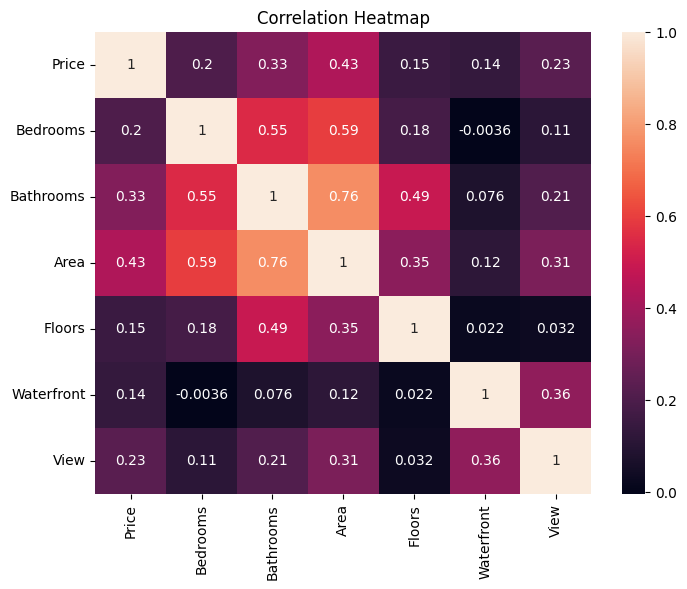

'area has strongest positive correlation with price\n while other shows weak to moderate positive relatipnship.'

In [196]:

#Correlation Heat Map -to find the relation,Which Numeric Feature is related to the House Price
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.title("Correlation Heatmap")
plt.show()
'''area has strongest positive correlation with price
 while other shows weak to moderate positive relatipnship.'''

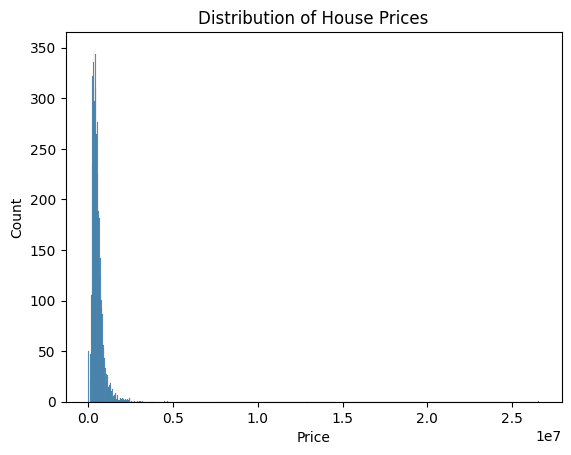

In [197]:
#Price distribution-shows how house price are distributed
sns.histplot(df['Price'])
plt.title("Distribution of House Prices")
plt.show()

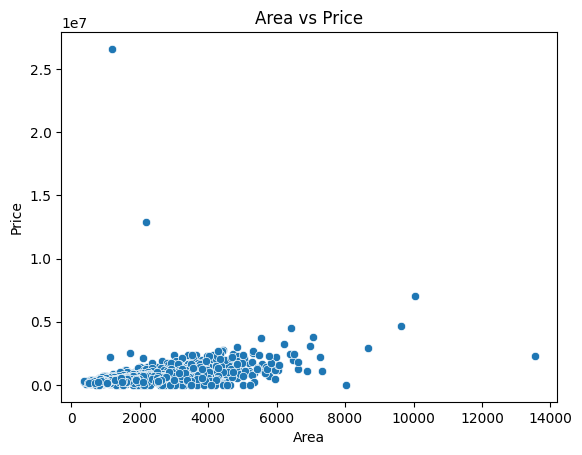

In [198]:
#(Scatter Plot) :Shows the relationship between area and price.
sns.scatterplot(x='Area', y='Price', data=df)
plt.title("Area vs Price")
plt.show()

# **Outlier Detection**

Outliers are extreme values that differ significantly from the rest of the data and can negatively affect the performance of regression models. Therefore, the dataset is analyzed to identify potential outliers before model training.

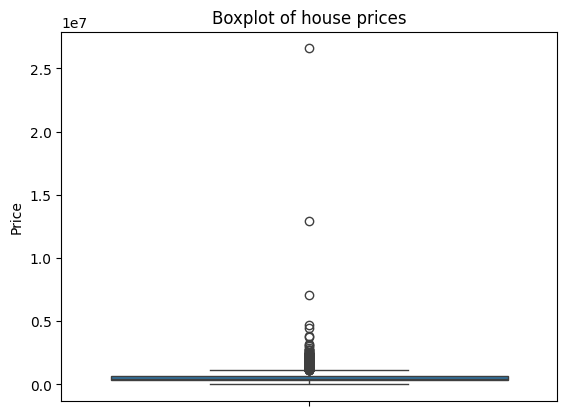

In [199]:
#Boxplot-Chceks the outliers in the target variable(price)
sns.boxplot(df["Price"])
plt.title("Boxplot of house prices")
plt.show()

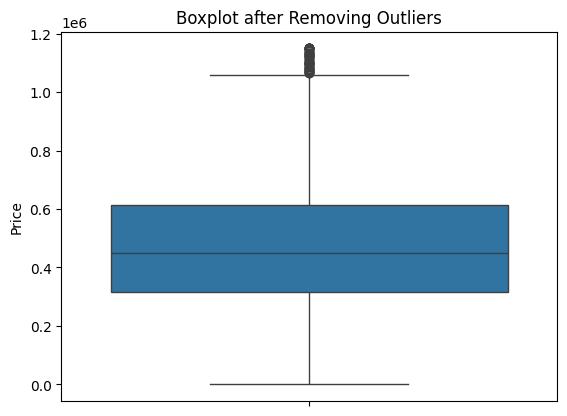

In [200]:
#Handle Outliers
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1
df = df[(df['Price'] >= (Q1 - 1.5*IQR)) & (df['Price'] <= (Q3 + 1.5*IQR))]
sns.boxplot(y=df['Price'])
plt.title("Boxplot after Removing Outliers")
plt.show()

Outliers were detected using the Interquartile Range (IQR) method and removed from the dataset to improve data quality and reduce their impact on model performance.


# **Feature Encoding**

Machine learning models require numerical input for training. Therefore, categorical features are converted into numerical format using **One-Hot Encoding**, which creates separate binary columns for each category without introducing ordinal relationships.

In [201]:
#Categorical Feature Encoding
df = pd.get_dummies(df, columns=['Location'], drop_first=True)
df.head()

,Price,Bedrooms,Bathrooms,Area,Floors,Waterfront,View,Location_Auburn,Location_Beaux Arts Village,Location_Bellevue,...,Location_SeaTac,Location_Seattle,Location_Shoreline,Location_Skykomish,Location_Snoqualmie,Location_Snoqualmie Pass,Location_Tukwila,Location_Vashon,Location_Woodinville,Location_Yarrow Point
0,313000.0,3,1.50,1340,1.5,0,0,False,False,False,...,False,False,True,False,False,False,False,False,False,False
2,342000.0,3,2.00,1930,1.0,0,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,420000.0,3,2.25,2000,1.0,0,0,False,False,True,...,False,False,False,False,False,False,False,False,False,False
4,550000.0,4,2.50,1940,1.0,0,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,490000.0,2,1.00,880,1.0,0,0,False,False,False,...,False,True,False,False,False,False,False,False,False,False


Categorical features were successfully encoded using One-Hot Encoding, making the dataset suitable for training regression models.


# **Data Preparation**


In [202]:
#Seperate Features and Target
X=df.drop('Price',axis=1)
y=df['Price']


In [203]:
#Split into training and Testing
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

# **Feature Scaling**

Feature scaling is performed to standardize numerical features, ensuring they are on a similar scale for effective model training.

In [204]:
#Feature Scaling
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

# **Model Building**

In [205]:
#LinearRegression
lr=LinearRegression()
lr.fit(X_train_scaled,y_train)
y_pred_lr=lr.predict(X_test_scaled)


In [206]:
#Ridge Regression
ridge=Ridge()
ridge.fit(X_train_scaled,y_train)
y_pred_ridge=ridge.predict(X_test_scaled)

In [207]:
#Lasso Regression
lasso=Lasso(max_iter=10000)
lasso.fit(X_train_scaled,y_train)
y_pred_lasso=lasso.predict(X_test_scaled)

The performance of the trained regression models is evaluated using MAE, MSE, RMSE, and R² Score.

# **Model Evaluation**

The performance of Linear Regression, Ridge Regression, and Lasso Regression is compared using MAE, MSE, RMSE, and R² Score to identify the most suitable model for house price prediction.

In [208]:
#LinearRegression
mae_lr=mean_absolute_error(y_test,y_pred_lr)
mse_lr=mean_squared_error(y_test,y_pred_lr)
rmse_lr=np.sqrt(mse_lr)
r2_score_lr=r2_score(y_test,y_pred_lr)

print("Linear Regression Metrics:")
print("Mean Absolute Error:", mae_lr)
print("Mean Squared Error:", mse_lr)
print("Root Mean Squared Error:", rmse_lr)
print("R-squared Score:", r2_score_lr)
print("\n")

#Ridge Regression
mae_ridge=mean_absolute_error(y_test,y_pred_ridge)
mse_ridge=mean_squared_error(y_test,y_pred_ridge)
rmse_ridge=np.sqrt(mse_ridge)
r2_score_ridge=r2_score(y_test,y_pred_ridge)

print("Ridge Regression Metrics:")
print("Mean Absolute Error:", mae_ridge)
print("Mean Squared Error:", mse_ridge)
print("Root Mean Squared Error:", rmse_ridge)
print("R-squared Score:", r2_score_ridge)
print("\n")
#Lasso Regression
mae_lasso=mean_absolute_error(y_test,y_pred_lasso)
mse_lasso=mean_squared_error(y_test,y_pred_lasso)
rmse_lasso=np.sqrt(mse_lasso)
r2_score_lasso=r2_score(y_test,y_pred_lasso)

print("Lasso Regression Metrics:")
print("Mean Absolute Error:", mae_lasso)
print("Mean Squared Error:", mse_lasso)
print("Root Mean Squared Error:", rmse_lasso)
print("R-squared Score:", r2_score_lasso)
print("\n")

Linear Regression Metrics:
Mean Absolute Error: 101288.42502500249
Mean Squared Error: 25636327703.08632
Root Mean Squared Error: 160113.4838265857
R-squared Score: 0.49265579237108004


Ridge Regression Metrics:
Mean Absolute Error: 101289.02286805194
Mean Squared Error: 25635105099.67765
Root Mean Squared Error: 160109.66585336954
R-squared Score: 0.4926799877536948


Lasso Regression Metrics:
Mean Absolute Error: 101288.79930613193
Mean Squared Error: 25636223789.26124
Root Mean Squared Error: 160113.15932571326
R-squared Score: 0.49265784883087627




Among the regression models, **Ridge Regression achieved the best overall performance** with the highest R² Score and the lowest prediction error. Therefore, it was selected as the most suitable model for house price prediction.

Best RMSE-Ridge Regression(Lower)

Best r2score-Ridge Regression(higher)

Best MAE- Linear Regression(lower)


# **Model Visualization**

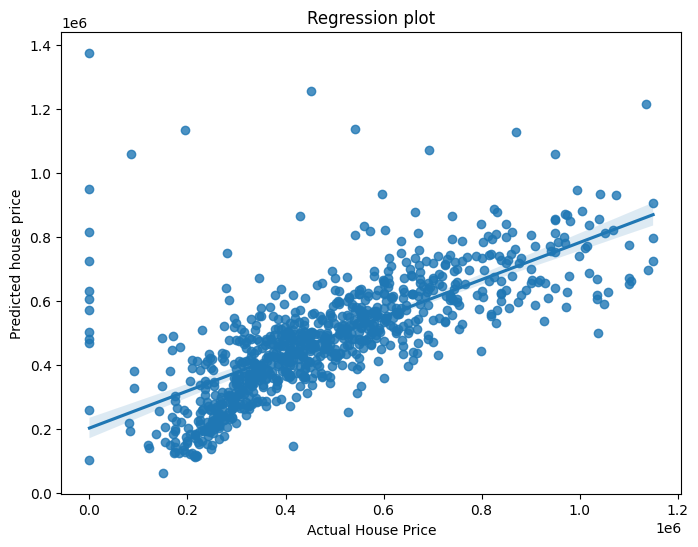

In [209]:
#Regression plot
plt.figure(figsize=(8,6))
sns.regplot(x=y_test,y=y_pred_ridge)
plt.title("Regression plot")
plt.xlabel("Actual House Price")
plt.ylabel("Predicted house price")
plt.show()

The regression plot shows that the predicted prices closely follow the actual prices, indicating good model performance.

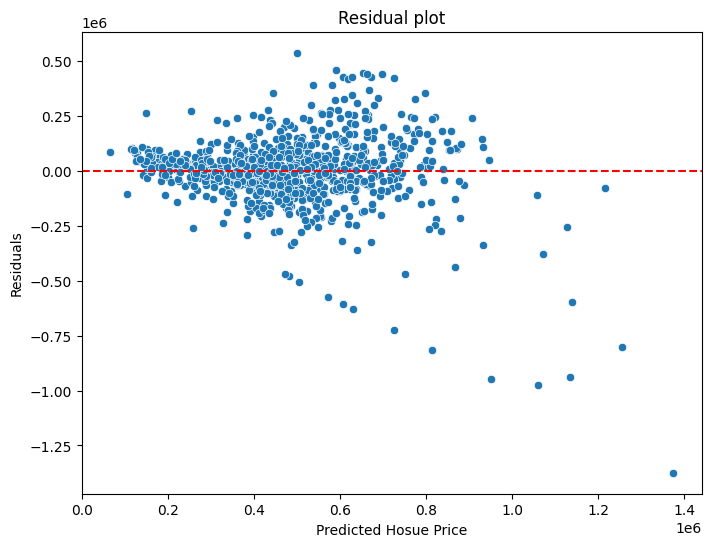

In [210]:
#Residual Plot

residuals=y_test- y_pred_ridge
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_pred_ridge,y=residuals)
plt.axhline(y=0,color='red',linestyle='--')
plt.title("Residual plot")
plt.xlabel("Predicted Hosue Price")
plt.ylabel("Residuals")
plt.show()


 The residuals are randomly distributed around zero, suggesting that the model captures the overall relationship without significant bias.

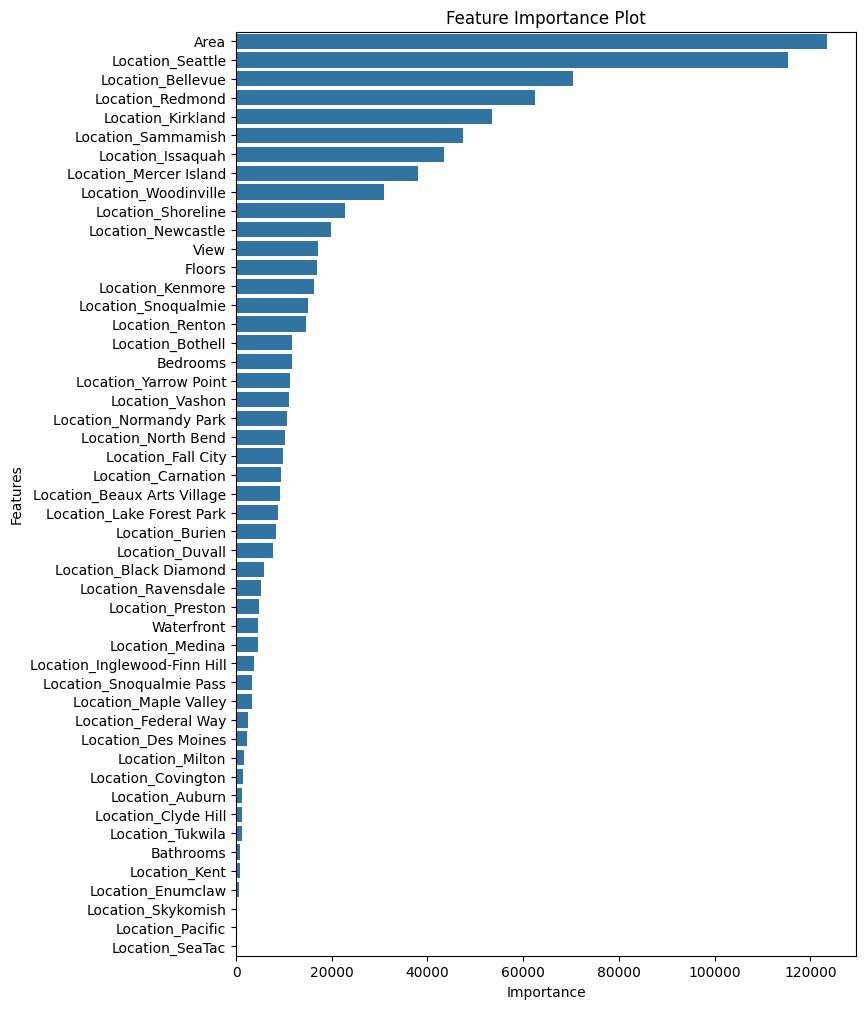

In [213]:
#Feature Importance Plot
feature_importance=pd.DataFrame({'Feature':X.columns,'Importance':ridge.coef_})

feature_importance['Importance']=abs(feature_importance['Importance'])
feature_importance=feature_importance.sort_values(by='Importance',ascending=False)

plt.figure(figsize=(8,12))
sns.barplot(x='Importance',y='Feature',data=feature_importance)
plt.title("Feature Importance Plot")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

 Area and bathrooms have a stronger influence on house prices, while some encoded categorical features contribute less to the prediction.

# **Conclusion**

This project successfully developed and evaluated multiple regression models for house price prediction. Among the models, Ridge Regression achieved the best performance based on the evaluation metrics, making it the most suitable model for predicting house prices on this dataset.The developed model can assist real estate professionals and buyers in estimating house prices more accurately based on property features